# HW13: Tokenization, Pretrained Inference and Fine-Tuning for Text Classification

В этой работе используется датасет `emotion`. В ноутбуке показаны:
- sanity-check текстового датасета;
- разбор токенизации нескольких примеров;
- инференс готовой pretrained модели;
- fine-tuning одной BERT-подобной модели;
- финальная оценка на test и сохранение минимальных артефактов.


## 1. Импорты, seed, среда и папки для артефактов


In [20]:
import csv
import json
import random
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
from datasets import ClassLabel, load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, pipeline

%matplotlib inline
plt.style.use("ggplot")

ROOT = Path(".")
ARTIFACTS_DIR = ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

SEED = 42
DATASET_NAME = "emotion"
INFERENCE_MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"
FINETUNE_MODEL_NAME = "distilbert-base-uncased"
TEXT_COLUMN = "text"
LABEL_COLUMN = "label"
MAX_LENGTH = 96
BATCH_SIZE = 32
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Seed:", SEED)
print("Artifacts:", ARTIFACTS_DIR.resolve())


Device: cpu
Seed: 42
Artifacts: C:\Users\vt240\OneDrive\Рабочий стол\prog\II-cafedra\aie-student-template\homeworks\HW13\artifacts


## 2. Данные и первичный анализ


In [21]:
raw_datasets = load_dataset(DATASET_NAME)
print(raw_datasets)

train_ds = raw_datasets["train"]
val_ds = raw_datasets["validation"]
test_ds = raw_datasets["test"]

label_feature = train_ds.features[LABEL_COLUMN]
if isinstance(label_feature, ClassLabel):
    label_names = label_feature.names
else:
    label_names = sorted(set(train_ds[LABEL_COLUMN]))

print("Label names:", label_names)
print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
print("Test size:", len(test_ds))


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Train size: 16000
Validation size: 2000
Test size: 2000


In [22]:
sample_df = pd.DataFrame({
    "text": train_ds[TEXT_COLUMN][:5],
    "label_id": train_ds[LABEL_COLUMN][:5],
})
sample_df["label_name"] = sample_df["label_id"].map(lambda x: label_names[x])
display(sample_df)

print(
    "Задача: по короткому тексту предсказать эмоцию. "
    "Датасет содержит 6 классов и официальные split train/validation/test, "
    "поэтому отдельное ручное разбиение не требуется."
)


,text,label_id,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Задача: по короткому тексту предсказать эмоцию. Датасет содержит 6 классов и официальные split train/validation/test, поэтому отдельное ручное разбиение не требуется.


## 3. Токенизация


In [23]:
tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME, use_fast=True)
example_texts = train_ds[TEXT_COLUMN][:5]

print("Tokenizer:", FINETUNE_MODEL_NAME)
print("CLS token:", tokenizer.cls_token)
print("SEP token:", tokenizer.sep_token)
print("PAD token:", tokenizer.pad_token)
print("UNK token:", tokenizer.unk_token)


Tokenizer: distilbert-base-uncased
CLS token: [CLS]
SEP token: [SEP]
PAD token: [PAD]
UNK token: [UNK]


In [24]:
tokenization_rows = []
for text in example_texts:
    encoded = tokenizer(text, padding="max_length", truncation=True, max_length=24)
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    tokenization_rows.append({
        "text": text,
        "tokens": tokens,
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
    })

for idx, row in enumerate(tokenization_rows, start=1):
    print(f"Example {idx}")
    print("text:", row["text"])
    print("tokens:", row["tokens"])
    print("input_ids:", row["input_ids"])
    print("attention_mask:", row["attention_mask"])
    print("-" * 100)


Example 1
text: i didnt feel humiliated
tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
----------------------------------------------------------------------------------------------------
Example 2
text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
tokens: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]', '[PAD]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 26

In [25]:
with open(ARTIFACTS_DIR / "tokenization_examples.txt", "w", encoding="utf-8") as f:
    for idx, row in enumerate(tokenization_rows, start=1):
        f.write(f"Example {idx}\n")
        f.write(f"text: {row['text']}\n")
        f.write(f"tokens: {row['tokens']}\n")
        f.write(f"input_ids: {row['input_ids']}\n")
        f.write(f"attention_mask: {row['attention_mask']}\n")
        f.write("-" * 100 + "\n")

print("Saved tokenization_examples.txt")


Saved tokenization_examples.txt


## 4. Инференс готовой pretrained модели


In [26]:
inference_pipe = pipeline(
    "text-classification",
    model=INFERENCE_MODEL_NAME,
    tokenizer=INFERENCE_MODEL_NAME,
    device=0 if torch.cuda.is_available() else -1,
)

inference_examples = [
    "I am so happy that everything worked out perfectly.",
    "This is absolutely terrifying and I want to leave.",
    "I feel disappointed and tired after that conversation.",
    "What a wonderful surprise, I did not expect this at all.",
    "I am really angry that they ignored the problem again.",
]

inference_results = inference_pipe(inference_examples)
inference_df = pd.DataFrame({
    "text": inference_examples,
    "pred_label": [item["label"] for item in inference_results],
    "score": [item["score"] for item in inference_results],
})
display(inference_df)

print(
    "Готовая pretrained emotion-модель даёт разумные предсказания на общих примерах эмоций, "
    "но её label space и доменная настройка не обязательно полностью совпадают с выбранным датасетом. "
    "Поэтому для целевой задачи всё равно нужен fine-tuning на train/validation выбранного набора данных."
)


C:\Users\vt240\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vt240\.cache\huggingface\hub\models--j-hartmann--emotion-english-distilroberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 33916.20it/s]
RobertaFo

,text,pred_label,score
0,I am so happy that everything worked out perfe...,joy,0.990012
1,This is absolutely terrifying and I want to le...,fear,0.992658
2,I feel disappointed and tired after that conve...,sadness,0.960571
3,"What a wonderful surprise, I did not expect th...",surprise,0.882304
4,I am really angry that they ignored the proble...,anger,0.984489


Готовая pretrained emotion-модель даёт разумные предсказания на общих примерах эмоций, но её label space и доменная настройка не обязательно полностью совпадают с выбранным датасетом. Поэтому для целевой задачи всё равно нужен fine-tuning на train/validation выбранного набора данных.


## 5. Подготовка датасета для fine-tuning


In [27]:
def tokenize_batch(batch):
    return tokenizer(batch[TEXT_COLUMN], truncation=True, max_length=MAX_LENGTH)

tokenized_datasets = raw_datasets.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns([TEXT_COLUMN])
tokenized_datasets = tokenized_datasets.rename_column(LABEL_COLUMN, "labels")
tokenized_datasets.set_format("torch")

collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(tokenized_datasets["train"], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator)
val_loader = DataLoader(tokenized_datasets["validation"], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)
test_loader = DataLoader(tokenized_datasets["test"], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Map: 100%|██████████| 2000/2000 [00:00<00:00, 17451.07 examples/s]

Train batches: 500
Validation batches: 63
Test batches: 63


## 6. Fine-tuning одной BERT-подобной модели


In [28]:
model = AutoModelForSequenceClassification.from_pretrained(
    FINETUNE_MODEL_NAME,
    num_labels=len(label_names),
).to(device)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)


def batch_to_device(batch):
    return {k: v.to(device) for k, v in batch.items()}


@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    losses = []
    preds = []
    labels = []
    confidences = []

    for batch in loader:
        batch = batch_to_device(batch)
        outputs = model(**batch)
        losses.append(outputs.loss.item())
        probabilities = torch.softmax(outputs.logits, dim=-1)
        batch_preds = probabilities.argmax(dim=-1)
        batch_conf = probabilities.max(dim=-1).values
        preds.extend(batch_preds.cpu().numpy().tolist())
        labels.extend(batch["labels"].cpu().numpy().tolist())
        confidences.extend(batch_conf.cpu().numpy().tolist())

    metrics = {
        "loss": float(np.mean(losses)),
        "accuracy": float(accuracy_score(labels, preds)),
        "f1_macro": float(f1_score(labels, preds, average="macro")),
    }
    return metrics, np.array(preds), np.array(labels), np.array(confidences)


def train_model(model, train_loader, val_loader, num_epochs):
    history = {"train_loss": [], "val_loss": [], "val_accuracy": [], "val_f1_macro": []}
    best_state = None
    best_metrics = None
    best_val_f1 = -1.0

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_losses = []

        for batch in train_loader:
            batch = batch_to_device(batch)
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        val_metrics, _, _, _ = evaluate_model(model, val_loader)
        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_f1_macro"].append(val_metrics["f1_macro"])

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train_loss={history['train_loss'][-1]:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1_macro={val_metrics['f1_macro']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            best_state = deepcopy(model.state_dict())
            best_metrics = val_metrics

    model.load_state_dict(best_state)
    return model, history, best_metrics


C:\Users\vt240\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vt240\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 23412.25it/s]
DistilBertForSequenceClassificat

In [29]:
model, history, best_val_metrics = train_model(model, train_loader, val_loader, NUM_EPOCHS)
print("Best validation metrics:", best_val_metrics)


Epoch 01/3 | train_loss=0.5571 | val_loss=0.2000 | val_acc=0.9215 | val_f1_macro=0.8917
Epoch 02/3 | train_loss=0.1530 | val_loss=0.1664 | val_acc=0.9255 | val_f1_macro=0.8991
Epoch 03/3 | train_loss=0.1108 | val_loss=0.1437 | val_acc=0.9355 | val_f1_macro=0.9094
Best validation metrics: {'loss': 0.14367293814818063, 'accuracy': 0.9355, 'f1_macro': 0.9094198636374463}


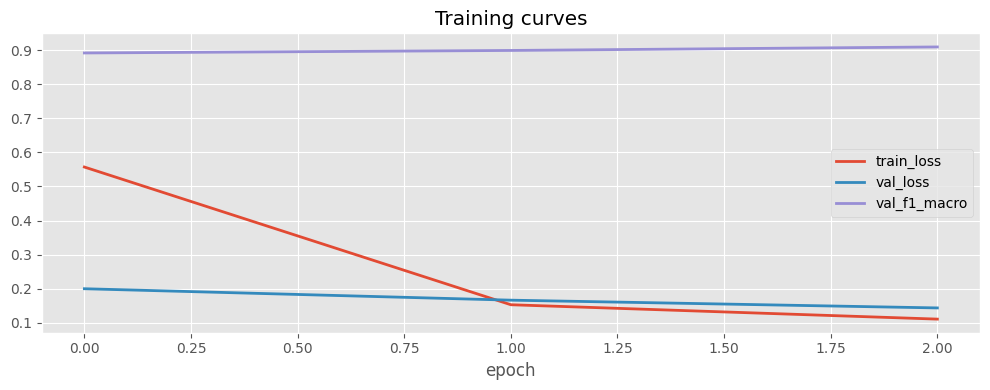

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="train_loss", linewidth=2)
plt.plot(history["val_loss"], label="val_loss", linewidth=2)
plt.plot(history["val_f1_macro"], label="val_f1_macro", linewidth=2)
plt.title("Training curves")
plt.xlabel("epoch")
plt.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Финальная оценка на test и анализ ошибок


In [31]:
test_metrics, test_preds, test_labels, test_confidences = evaluate_model(model, test_loader)
print("Final test metrics:")
print(test_metrics)


Final test metrics:
{'loss': 0.15440623972210146, 'accuracy': 0.933, 'f1_macro': 0.8959976613475824}


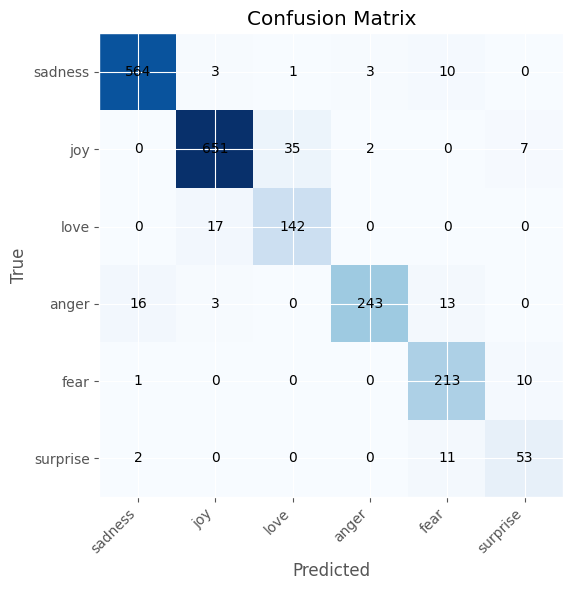

In [32]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(label_names)), label_names, rotation=45, ha="right")
plt.yticks(range(len(label_names)), label_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


In [33]:
test_texts = raw_datasets["test"][TEXT_COLUMN]
predictions_df = pd.DataFrame({
    "text": test_texts,
    "true_label": [label_names[idx] for idx in test_labels],
    "pred_label": [label_names[idx] for idx in test_preds],
    "confidence": test_confidences,
})
predictions_df.to_csv(ARTIFACTS_DIR / "sample_predictions.csv", index=False)

display(predictions_df.head(10))
display(predictions_df[predictions_df["true_label"] != predictions_df["pred_label"]].head(8))

print(
    "В ошибках особенно полезно смотреть на тексты с близкими эмоциями, например sadness vs fear или joy vs love. "
    "Такие случаи часто содержат короткие формулировки и неявный контекст, из-за чего модель путает соседние классы."
)


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.997781
1,im updating my blog because i feel shitty,sadness,sadness,0.998495
2,i never make her separate from me because i do...,sadness,sadness,0.998160
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.998482
4,i was feeling a little vain when i did this one,sadness,sadness,0.998313
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.989269
6,i felt anger when at the end of a telephone call,anger,anger,0.916284
7,i explain why i clung to a relationship with a...,joy,joy,0.801614
8,i like to have the same breathless feeling as ...,joy,joy,0.997214
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.995649


,text,true_label,pred_label,confidence
40,i feel if i completely hated things i d exerci...,anger,sadness,0.701308
67,i feel a bit stressed even though all the thin...,anger,sadness,0.767276
72,i am right handed however i play billiards lef...,surprise,fear,0.742827
86,i feel like i am in paradise kissing those swe...,joy,love,0.666108
94,when a friend dropped a frog down my neck,anger,fear,0.814854
98,i feel my heart is tortured by what i have done,anger,fear,0.793087
131,im feeling generous today heres one more you m...,love,joy,0.758343
137,i actually feel agitated which led to a terrib...,anger,fear,0.958042


В ошибках особенно полезно смотреть на тексты с близкими эмоциями, например sadness vs fear или joy vs love. Такие случаи часто содержат короткие формулировки и неявный контекст, из-за чего модель путает соседние классы.
